# Superstore Dashboard Audit

Before building the Power BI dashboards and the SQL layer, I wanted to understand
the data properly -- what the discount distribution looks like, whether KPI definitions
could cause consistency issues across multiple reports, and what the overall shape of
the dataset is.

This notebook is that analysis. Two things stood out that directly influenced the
design decisions in the migration.

Dataset: https://community.tableau.com/s/question/0D54T00000CWeX8SAL/sample-superstore-sales-excelxls

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
import seaborn as sns
sns.set_style('whitegrid')

### Load the data

In [2]:
from google.colab import files
import io

if 'uploaded' not in dir() or not uploaded:
    uploaded = files.upload()  # upload Sample - Superstore.xls

# it's an xls so we need xlrd
!pip install xlrd -q

key = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[key]), sheet_name='Orders', engine='xlrd')

print(df.shape)
print(f'orders: {df["Order ID"].nunique():,}')
print(f'customers: {df["Customer ID"].nunique():,}')
print(f'products: {df["Product ID"].nunique():,}')
print(f'date range: {df["Order Date"].min().date()} to {df["Order Date"].max().date()}')
df.head()

Saving Sample - Superstore.xls to Sample - Superstore.xls
(9994, 21)
orders: 5,009
customers: 793
products: 1,862
date range: 2014-01-03 to 2017-12-30


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# quick look at dtypes and nulls
print('dtypes:')
print(df.dtypes)
print()
print('nulls:')
print(df.isnull().sum()[df.isnull().sum() > 0])

dtypes:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

nulls:
Series([], dtype: int64)


### Profit margin — two methods, one needs to win

Profit margin can be calculated two ways on this data:
- **Order-level**: total profit / total sales for the whole order
- **Line-item-level**: average of each individual line's margin

These give different numbers any time an order has line items with different margin profiles,
which turns out to be most orders. If different reports use different methods,
the same order shows a different margin depending on which dashboard you're looking at.

Let's see how often the two methods actually diverge on this dataset.

In [4]:
# method 1: order-level margin (total profit / total sales per order)
order_margin = df.groupby('Order ID').apply(
    lambda x: x['Profit'].sum() / x['Sales'].sum() if x['Sales'].sum() != 0 else None
).dropna().rename('order_level_margin')

# method 2: line-item-level margin (avg of each line's individual margin)
df['line_margin'] = df['Profit'] / df['Sales'].replace(0, np.nan)
line_margin = df.groupby('Order ID')['line_margin'].mean().rename('line_item_margin')

margin_compare = pd.concat([order_margin, line_margin], axis=1).dropna()
margin_compare['diff'] = (margin_compare['order_level_margin'] - margin_compare['line_item_margin']).abs()

diverge = (margin_compare['diff'] > 0.01).sum()
total = len(margin_compare)

print(f'orders where methods differ by >1%: {diverge:,} out of {total:,} ({diverge/total*100:.0f}%)')
print(f'max difference: {margin_compare["diff"].max():.4f}')
print(f'mean difference: {margin_compare["diff"].mean():.4f}')

orders where methods differ by >1%: 2,077 out of 5,009 (41%)
max difference: 1.7683
mean difference: 0.0563


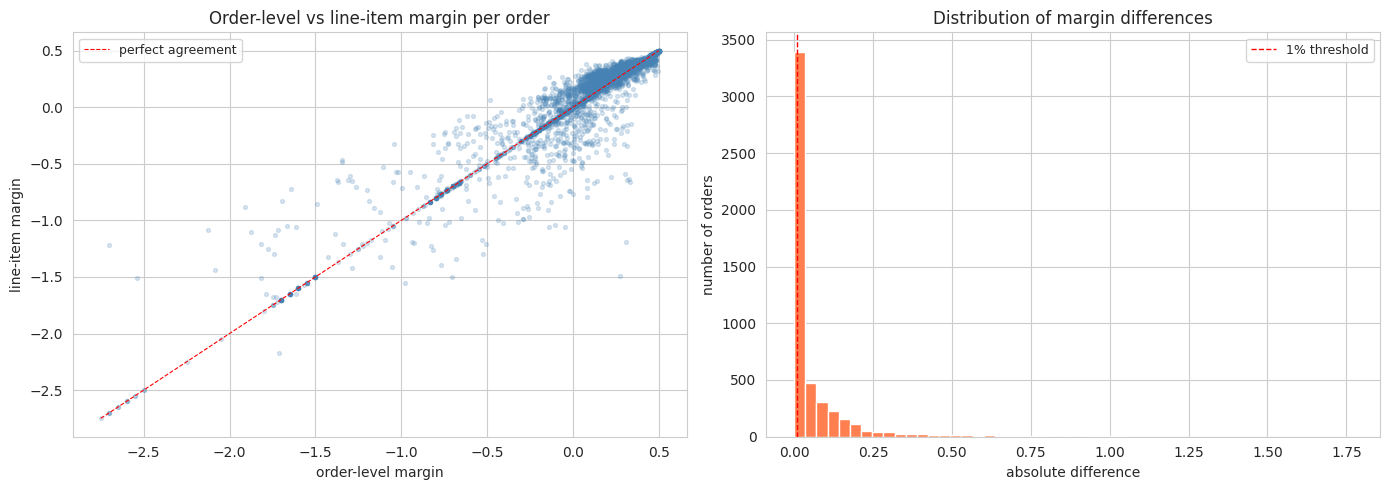

41% of orders show margin differences > 1% between the two methods


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    margin_compare['order_level_margin'],
    margin_compare['line_item_margin'],
    alpha=0.2, s=8, color='steelblue'
)
lims = [margin_compare[['order_level_margin','line_item_margin']].min().min(),
        margin_compare[['order_level_margin','line_item_margin']].max().max()]
axes[0].plot(lims, lims, 'r--', linewidth=0.8, label='perfect agreement')
axes[0].set_title('Order-level vs line-item margin per order')
axes[0].set_xlabel('order-level margin')
axes[0].set_ylabel('line-item margin')
axes[0].legend(fontsize=9)

axes[1].hist(margin_compare['diff'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(0.01, color='red', linestyle='--', linewidth=1, label='1% threshold')
axes[1].set_title('Distribution of margin differences')
axes[1].set_xlabel('absolute difference')
axes[1].set_ylabel('number of orders')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'{diverge/total*100:.0f}% of orders show margin differences > 1% between the two methods')

### Discount analysis — standardizing the bucketing

Discount bucketing is easy to define inconsistently. Does a 0.0 discount count as
'No Discount'? What about a null? Where does the 10-20% bucket start and end?
If each report defines this differently the numbers won't match across dashboards.

The plan is to define one bucketing logic in SQL that all reports connect to.
First let's look at what the actual discount distribution looks like and
what it means for margin.

In [6]:
print('Discount value distribution:')
print(f'  zero discount: {(df["Discount"] == 0).sum():,} rows ({(df["Discount"] == 0).mean()*100:.1f}%)')
print(f'  discounted: {(df["Discount"] > 0).sum():,} rows ({(df["Discount"] > 0).mean()*100:.1f}%)')
print()
print('Most common discount values:')
print(df['Discount'].value_counts().head(8))

Discount value distribution:
  zero discount: 4,798 rows (48.0%)
  discounted: 5,196 rows (52.0%)

Most common discount values:
Discount
0.0    4798
0.2    3657
0.7     418
0.8     300
0.3     227
0.4     206
0.6     138
0.1      94
Name: count, dtype: int64


In [7]:
df['discount_bucket'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 1.0],
    labels=['No Discount', '0-10%', '10-20%', '20-30%', '30%+']
)

bucket_stats = df.groupby('discount_bucket', observed=True).agg(
    row_count=('Sales', 'count'),
    total_sales=('Sales', 'sum'),
    total_profit=('Profit', 'sum'),
).reset_index()

bucket_stats['avg_margin_pct'] = (bucket_stats['total_profit'] / bucket_stats['total_sales'] * 100).round(1)
bucket_stats['pct_of_rows'] = (bucket_stats['row_count'] / len(df) * 100).round(1)

print(bucket_stats[['discount_bucket', 'row_count', 'pct_of_rows', 'avg_margin_pct']].to_string(index=False))

discount_bucket  row_count  pct_of_rows  avg_margin_pct
    No Discount       4798         48.0            29.5
          0-10%         94          0.9            16.6
         10-20%       3709         37.1            11.6
         20-30%        227          2.3           -10.0
           30%+       1166         11.7           -48.2


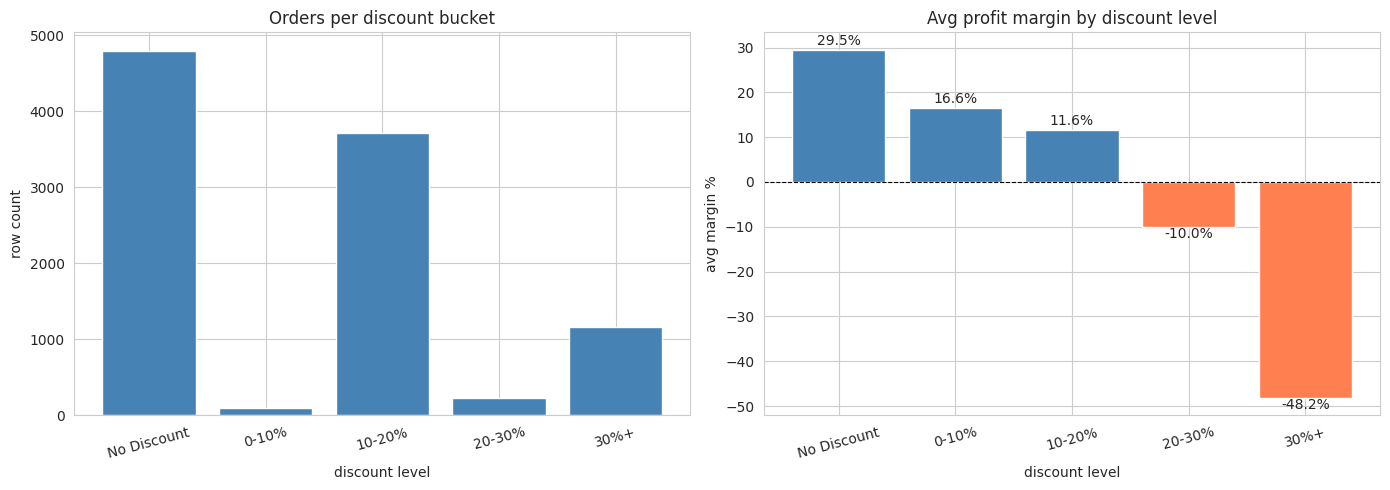

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue' if v >= 0 else 'coral' for v in bucket_stats['avg_margin_pct']]

axes[0].bar(bucket_stats['discount_bucket'], bucket_stats['row_count'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Orders per discount bucket')
axes[0].set_xlabel('discount level')
axes[0].set_ylabel('row count')
axes[0].tick_params(axis='x', rotation=15)

bars = axes[1].bar(bucket_stats['discount_bucket'], bucket_stats['avg_margin_pct'],
                   color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, bucket_stats['avg_margin_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (1 if val >= 0 else -2.5),
                 f'{val:.1f}%', ha='center', fontsize=10)
axes[1].set_title('Avg profit margin by discount level')
axes[1].set_xlabel('discount level')
axes[1].set_ylabel('avg margin %')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Additional EDA

In [9]:
# sales and profit by category
cat_stats = df.groupby('Category').agg(
    total_sales=('Sales', 'sum'),
    total_profit=('Profit', 'sum'),
    order_count=('Order ID', 'nunique')
).reset_index()
cat_stats['margin_pct'] = (cat_stats['total_profit'] / cat_stats['total_sales'] * 100).round(1)
print('by category:')
print(cat_stats.to_string(index=False))

by category:
       Category  total_sales  total_profit  order_count  margin_pct
      Furniture  741999.7953    18451.2728         1764         2.5
Office Supplies  719047.0320   122490.8008         3742        17.0
     Technology  836154.0330   145454.9481         1544        17.4


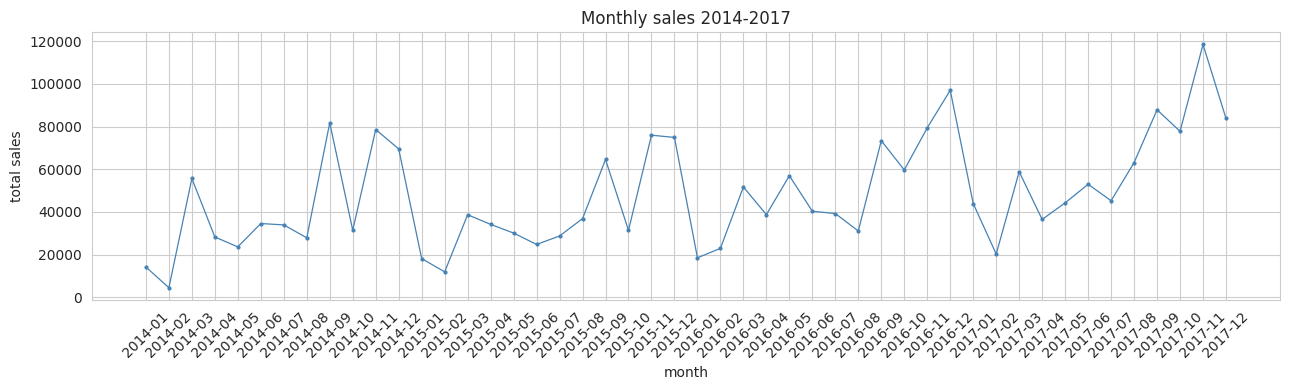

In [10]:
# monthly revenue trend
df['year_month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('year_month')['Sales'].sum()

plt.figure(figsize=(13, 4))
plt.plot(monthly.index.astype(str), monthly.values, color='steelblue', linewidth=0.9, marker='o', markersize=2)
plt.title('Monthly sales 2014-2017')
plt.xlabel('month')
plt.ylabel('total sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# segment breakdown
seg = df.groupby('Segment').agg(
    customers=('Customer ID', 'nunique'),
    orders=('Order ID', 'nunique'),
    total_sales=('Sales', 'sum'),
    total_profit=('Profit', 'sum')
).reset_index()
seg['margin_pct'] = (seg['total_profit'] / seg['total_sales'] * 100).round(1)
seg['avg_order_value'] = (seg['total_sales'] / seg['orders']).round(2)
print(seg.to_string(index=False))

    Segment  customers  orders  total_sales  total_profit  margin_pct  avg_order_value
   Consumer        409    2586 1161401.3450   134119.2092        11.5           449.11
  Corporate        236    1514  706146.3668    91979.1340        13.0           466.41
Home Office        148     909  429653.1485    60298.6785        14.0           472.67


### Summary

Two things from this analysis fed directly into the migration design:

**1. Profit margin standardization** — 41% of orders (2,077 out of 5,009) produce
a different margin number depending on calculation method. Rather than leave this
ambiguous across reports, profit_margin gets computed once at load time in SQL
using order-level calculation, so every report uses the same number.

**2. Discount bucketing** — defined a single standardized bucketing logic in
`v_discount_impact` that all reports connect to, so the discount breakdown
is always consistent.

The discount analysis also surfaced a useful business finding: orders with
20-30% discounts average -10.1% margin and 30%+ discounts average -48.2% margin,
vs +29.5% for undiscounted orders. High discounts aren't just reducing margin —
they're flipping orders into losses.

Both of these are now handled in the SQL layer, version-controlled and
consistent across every report.